In [ ]:
# step 1: import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#step 2: load 20 Newsgroups dataset
#we will use all categories to include all 20 newsgroups
categories = None
newsgroups = fetch_20newsgroups(subset='all', shuffle=True, random_state=42, categories=categories)



In [ ]:
#step 3: Explore the dataset (optional)
#print basic information to understant the categories
print("Number of documents:", len(newsgroups.data))
#step 3: Explore the dataset (optional)
#print basic information to understant the categories
print("Number of documents:", len(newsgroups.data))
print("Number of categories:", len(newsgroups.target_names))
print("Categories:", newsgroups.target_names)
print("Sample document:", newsgroups.data[0])


Number of documents: 18846
Number of documents: 18846
Number of categories: 20
Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
Sample document: From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are kill

In [ ]:
#cover the text data to TF-IDF features
#Tfidfvectorizer transforms text into numerical using  ml models
# Change max_features to an integer or None
# For example, to keep the 5000 most frequent words:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, min_df=2)
X = vectorizer.fit_transform(newsgroups.data)
y = newsgroups.target

In [ ]:
#step 5: split the dataset into training and test sets
# 80% training data, 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#step 6: intiazing the random data classifier
#set the number of estimated andrandom foresa
RandomForestClassifier(n_estimators=100, random_state=42)

RandomForestClassifier(random_state=42)

In [ ]:
#step 6: intiazing the random data classifier
#set the number of estimated andrandom foresa
# Assign the RandomForestClassifier instance to the variable 'rfc'
rfc = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
#step 7:train the rondom forest model
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# step 8: make the prediction on the data
y_pred = rfc.predict(X_test) # Added this line to generate predictions

In [ ]:
# step 9
# Evaluate the model's performance


# step 9
# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:(accuracy * 100 :.2f )%")

Accuracy:(accuracy * 100 :.2f )%


In [ ]:
#step 10: print the
#step 10: print the
#CM =CM(y_test, y_pred)
plt.figure(figsize=(9, 7))
from sklearn.metrics import classification_report
CR = classification_report(y_test, y_pred, target_names=newsgroups.target_names)
print("Classification Report:\n", CR)



Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.84      0.78      0.81       151
           comp.graphics       0.69      0.72      0.71       202
 comp.os.ms-windows.misc       0.72      0.85      0.78       195
comp.sys.ibm.pc.hardware       0.64      0.67      0.65       183
   comp.sys.mac.hardware       0.83      0.79      0.81       205
          comp.windows.x       0.89      0.74      0.81       215
            misc.forsale       0.79      0.78      0.78       193
               rec.autos       0.83      0.82      0.83       196
         rec.motorcycles       0.91      0.90      0.91       168
      rec.sport.baseball       0.86      0.91      0.88       211
        rec.sport.hockey       0.92      0.93      0.93       198
               sci.crypt       0.94      0.90      0.92       201
         sci.electronics       0.68      0.65      0.67       202
                 sci.med       0.79      0.88      

<Figure size 900x700 with 0 Axes>

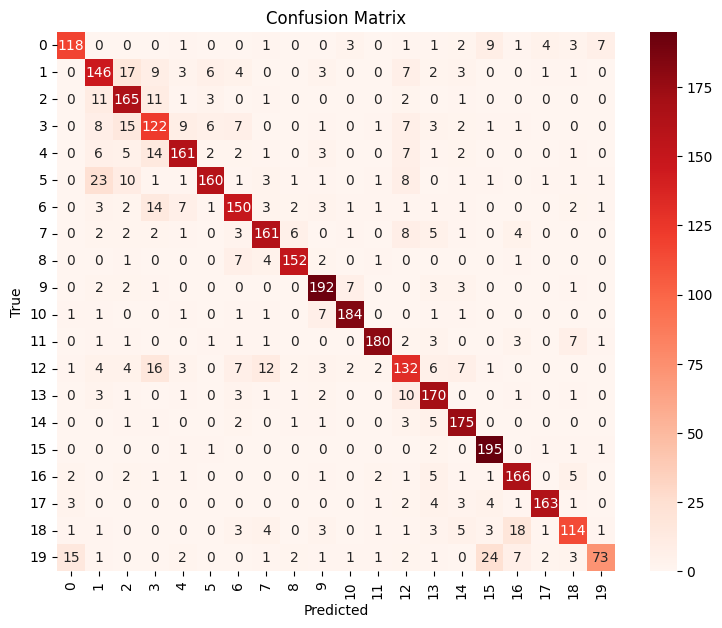

In [ ]:
#step 11 polt a confusion np.matrix
#this will show the classification performance for each class
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

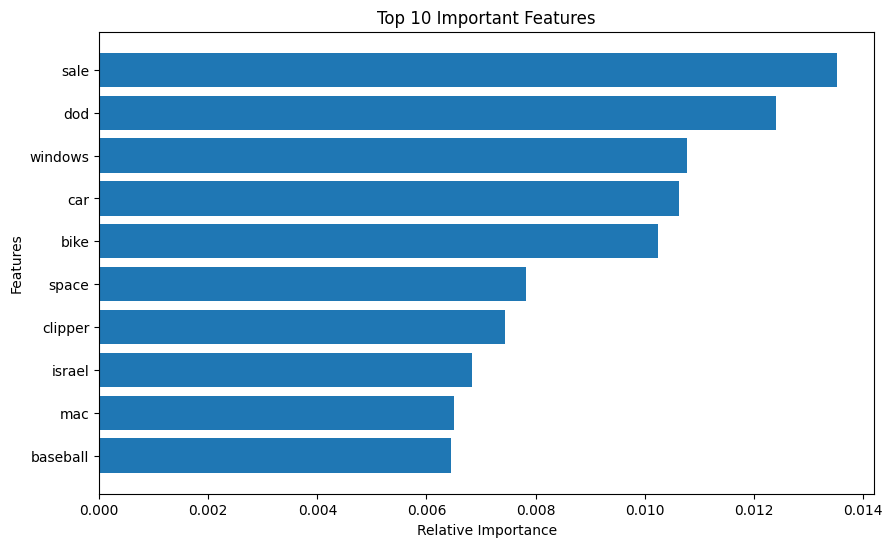

In [ ]:
#step 12 plot features
#random forest allows us to inspct
#step 12 plot features
#random forest allows us to inspct
importances = rfc.feature_importances_
indices = np.argsort(importances)[-10:]
feature_names = [vectorizer.get_feature_names_out()[i] for i in indices]
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), feature_names)
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.title('Top 10 Important Features')
plt.show()

